In [1]:
import pandas as pd

In [4]:
df=pd.read_csv("D:/ML Internship/placement_lyst1729240397995.csv")
print(df)

     cgpa  placement_exam_marks  placed
0    7.19                  26.0       1
1    7.46                  38.0       1
2    7.54                  40.0       1
3    6.42                   8.0       1
4    7.23                  17.0       0
..    ...                   ...     ...
995  8.87                  44.0       1
996  9.12                  65.0       1
997  4.89                  34.0       0
998  8.62                  46.0       1
999  4.90                  10.0       1

[1000 rows x 3 columns]


## How to detect Outliers?

1. In case of Normal Distribution/Standard Normal Distribution- Use Z score method(Emperical Formula Rule).
2. In case of Skewness- Use Inter-Quartile Range(Box plot method).

In [5]:
import seaborn as sns

C:\Users\Divyanshi Kesharwani\AppData\Local\Temp\ipykernel_83792\1539133731.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["cgpa"])


<Axes: xlabel='cgpa', ylabel='Density'>

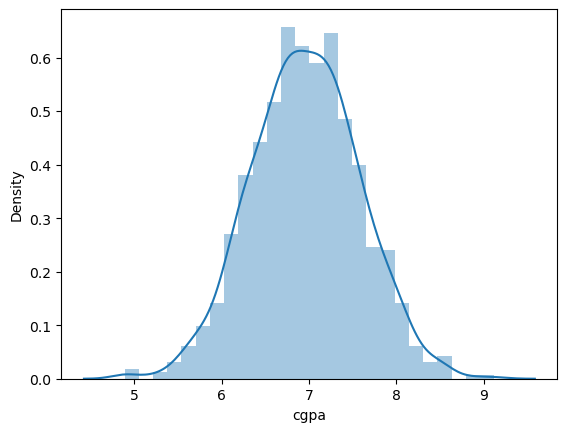

In [38]:
sns.distplot(df["cgpa"])
#For SND

<Axes: ylabel='cgpa'>

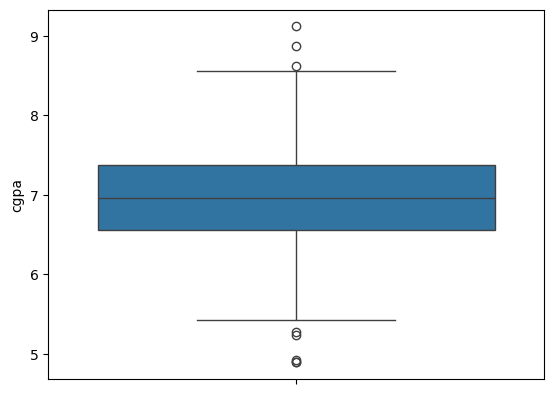

In [21]:
sns.boxplot(y="cgpa",data=df)

In [10]:
lower_fence=df["cgpa"].mean()-3*(df["cgpa"].std())
upper_fence=df["cgpa"].mean()+3*(df["cgpa"].std())
print(upper_fence)
print(lower_fence)

8.808933625397168
5.113546374602832


In [12]:
[df["cgpa"]<lower_fence]

[0      False
 1      False
 2      False
 3      False
 4      False
        ...  
 995    False
 996    False
 997     True
 998    False
 999     True
 Name: cgpa, Length: 1000, dtype: bool]

In [13]:
df[df["cgpa"]<lower_fence]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [14]:
[df["cgpa"]>upper_fence]

[0      False
 1      False
 2      False
 3      False
 4      False
        ...  
 995     True
 996     True
 997    False
 998    False
 999    False
 Name: cgpa, Length: 1000, dtype: bool]

In [32]:
df[df["cgpa"]>upper_fence]

,cgpa,placement_exam_marks,placed
995,8.87,44.0,1
996,9.12,65.0,1


C:\Users\Divyanshi Kesharwani\AppData\Local\Temp\ipykernel_83792\229708746.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["placement_exam_marks"])


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

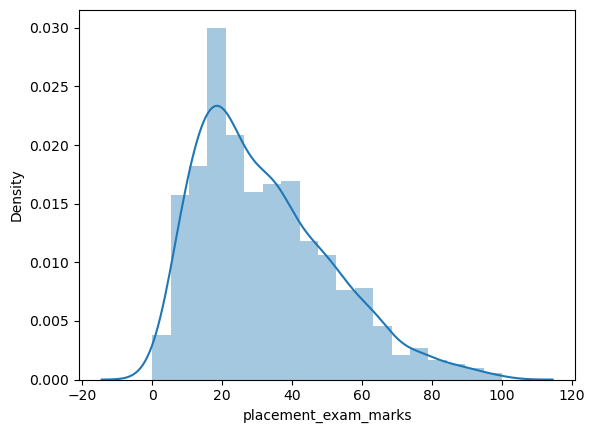

In [18]:
sns.distplot(df["placement_exam_marks"])
#Positively Skewed

<Axes: ylabel='placement_exam_marks'>

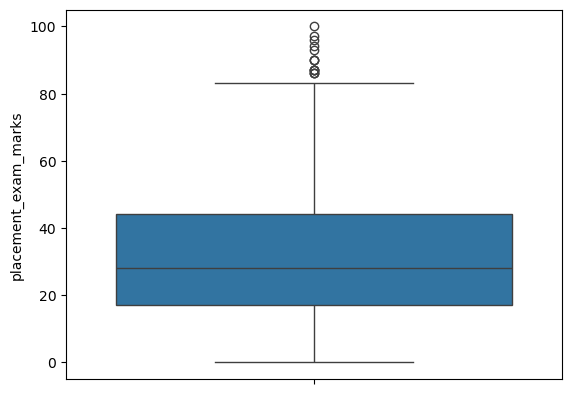

In [20]:
sns.boxplot(y="placement_exam_marks",data=df)

In [23]:
q1=df["placement_exam_marks"].quantile(0.25)
q3=df["placement_exam_marks"].quantile(0.75)
print(q1)
print(q3)

17.0
44.0


In [24]:
iqr=q3-q1
print(iqr)
upper=q3+1.5*iqr
lower=q1-1.5*iqr
print(upper)
print(lower)

27.0
84.5
-23.5


In [25]:
df[df["placement_exam_marks"]>upper]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [27]:
df[df["placement_exam_marks"]<lower]
#That's why positively skewed

,cgpa,placement_exam_marks,placed


C:\Users\Divyanshi Kesharwani\AppData\Local\Temp\ipykernel_83792\4056227218.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["placed"])


<Axes: xlabel='placed', ylabel='Density'>

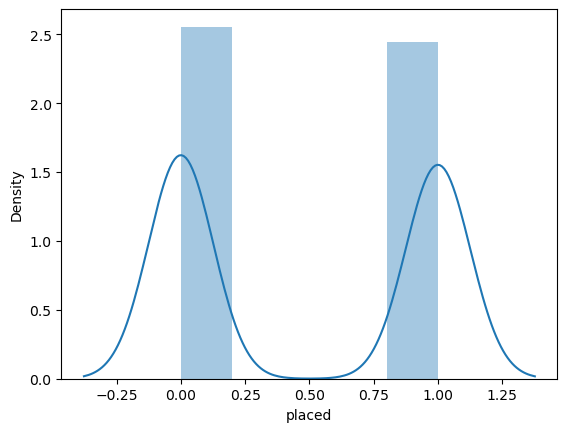

In [31]:
sns.distplot(df["placed"])
#No SND

<Axes: ylabel='placed'>

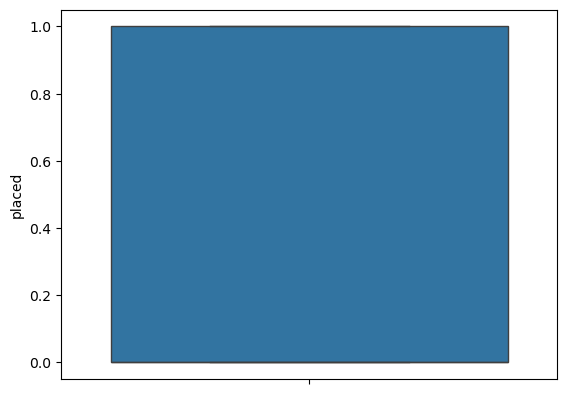

In [30]:
sns.boxplot(y="placed",data=df)

## Treatment of Outliers by deleting it

### For SND

In [37]:
df[(df["cgpa"]>lower_fence) & (df["cgpa"]<upper_fence)]

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


### For Skewed graph

In [39]:
df[(df["placement_exam_marks"]>lower) & (df["placement_exam_marks"]<upper)]

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


## Treatment of Outliers by Capping

### For SND

In [40]:
import numpy as np

In [41]:
cap=df.copy()

In [45]:
cap["placement_exam_marks"]=np.where(cap["placement_exam_marks"]>upper,upper,np.where(cap["placement_exam_marks"]<lower,lower,cap["placement_exam_marks"]))
print(cap["placement_exam_marks"])

0      26.0
1      38.0
2      40.0
3       8.0
4      17.0
       ... 
995    44.0
996    65.0
997    34.0
998    46.0
999    10.0
Name: placement_exam_marks, Length: 1000, dtype: float64


In [47]:
cap[upper<df["placement_exam_marks"]]

,cgpa,placement_exam_marks,placed
9,7.75,84.5,1
40,6.60,84.5,1
61,7.51,84.5,0
134,6.33,84.5,0
162,7.80,84.5,0
283,7.09,84.5,0
290,8.38,84.5,0
311,6.97,84.5,1
324,6.64,84.5,0
630,6.56,84.5,1
